## Import

Installation du toolkit aeon

In [1]:
!pip install -U aeon

  Using cached numpy-2.2.6-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 80.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 53.1 MB/s  0:00:006m0:00:0100:01
Using cached numpy-2.2.6-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
Using cached pandas-2.3.3-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.3 MB)
Using cached scikit_learn-1.7.2-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 56.8 MB/s  0:00:006m0:00:01
Usin

Installation du package MCM

In [1]:
!pip install multi-comp-matrix

Import des bibliothèques classiques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

## Chargement du jeu de données univarié Italy_power_demand

In [3]:
from aeon.datasets import load_italy_power_demand

Chargement du jeu de données

In [4]:
X_train, y_train = load_italy_power_demand(split="train")
X_test, y_test = load_italy_power_demand(split="test")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(67, 1, 24) (67,) (1029, 1, 24) (1029,)


Visualisation du jeu de données

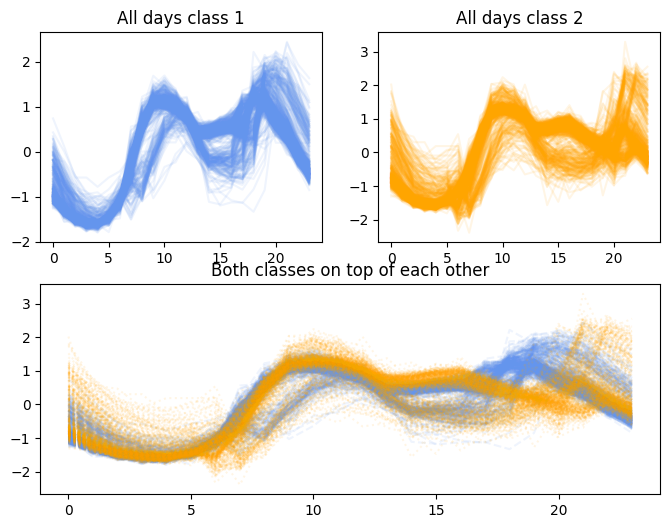

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs[1, 1].axis("off")
axs[1, 0].axis("off")
ax_combined = fig.add_subplot(2, 1, (2, 3))
axs[0, 0].set_title("All days class 1")
axs[0, 1].set_title("All days class 2")
ax_combined.set_title("Both classes on top of each other")
for i in np.where(y_test == "1")[0]:
    axs[0, 0].plot(X_test[i][0], alpha=0.1, color="cornflowerblue", linestyle="solid")
    ax_combined.plot(X_test[i][0], alpha=0.1, color="cornflowerblue", linestyle="--")
for i in np.where(y_test == "2")[0]:
    axs[0, 1].plot(X_test[i][0], alpha=0.1, color="orange", linestyle="solid")
    ax_combined.plot(X_test[i][0], alpha=0.1, color="orange", linestyle=":")

## Modèle basé distance (kNN avec DTW)

In [6]:
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier

knn = KNeighborsTimeSeriesClassifier(distance="dtw", n_neighbors=3, weights="distance")



Entrainement

In [7]:
knn.fit(X_train, y_train)

,distance,'dtw'
,distance_params,None
,n_neighbors,3
,weights,'distance'
,n_jobs,1


Evaluation

In [8]:
knn_preds = knn.predict(X_test)
metrics.accuracy_score(y_test, knn_preds)

/home/basile/documents/github/perso/deep-learning/.venv/lib/python3.12/site-packages/aeon/distances/elastic/_dtw.py:385: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  x1, y1 = x[i], y[j]


0.9504373177842566

## Modèle basé caractéristiques (catch22)

In [9]:
from aeon.classification.feature_based import Catch22Classifier

catch22 = Catch22Classifier()
catch22.fit(X_train, y_train)
catch22_preds = catch22.predict(X_test)
metrics.accuracy_score(y_test, catch22_preds)

0.8775510204081632

## Modèle basé convolutions (Rocket)

In [10]:
from aeon.classification.convolution_based import RocketClassifier

rocket = RocketClassifier()
rocket.fit(X_train, y_train)
rocket_preds = rocket.predict(X_test)
metrics.accuracy_score(y_test, rocket_preds)

0.967930029154519

## Modèle d'apprentissage profond (LITETime)

In [11]:
from aeon.classification.deep_learning import LITETimeClassifier

# réduction du nombre d'époques pour l'exemple => performances dégradées
lite = LITETimeClassifier(n_epochs=50)
lite.fit(X_train, y_train)
lite_preds = lite.predict(X_test)
metrics.accuracy_score(y_test, lite_preds)

2026-02-12 15:08:45.355577: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 15:08:45.411212: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 15:08:47.728933: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 15:08:48.107870: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


0.49951409135082603

## Jeu de données multivariées (BasicMotion)

Testez différents modèles sur un jeu de données multivariées comme BasicMotion

In [12]:
from aeon.datasets import load_basic_motions

In [ ]:
# vos codes ici

## Comparaison des modèles sur l'archive UCR

In [ ]:
from aeon.benchmarking.results_loaders import get_estimator_results_as_array
from aeon.datasets.tsc_datasets import univariate

In [ ]:
names = ['KNeighborsTimeSeries','Rocket','Catch22','LITETime']

In [ ]:
results, present_names = get_estimator_results_as_array(
    names, univariate, include_missing=False
)
results.shape

(112, 4)

(<Figure size 600x230 with 1 Axes>, <Axes: >)

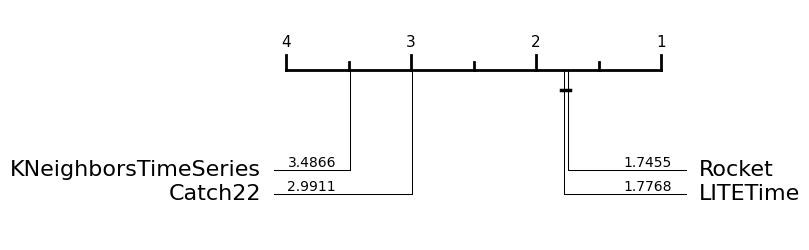

In [ ]:
from aeon.visualisation import plot_boxplot, plot_critical_difference

plot_critical_difference(results, names)

Visualisation avec la matrice MCM

Création du dataframe de résultats

In [ ]:
df_results= pd.DataFrame(results, columns=names)
df_results.head()

,KNeighborsTimeSeries,Rocket,Catch22,LITETime
0,0.640000,0.880000,0.850000,0.900000
1,0.603581,0.785166,0.716113,0.843990
2,0.702857,0.822857,0.725714,0.828571
3,0.633333,0.800000,0.600000,0.733333
4,0.700000,0.900000,0.750000,0.750000


Génération de la matrice MCM

In [ ]:
from multi_comp_matrix import MCM

MCM.compare(
        output_dir='./',
        df_results=df_results,
        pdf_savename="heatmap",
        png_savename="heatmap",
    )
# Matrice sauvegardée dans le dossier local au format PNG et PDF

Processing LITETime, Catch22:   0%|          | 0/4 [00:00<?, ?it/s]


./analysis.json


Chargement et affichage de la matrice MCM

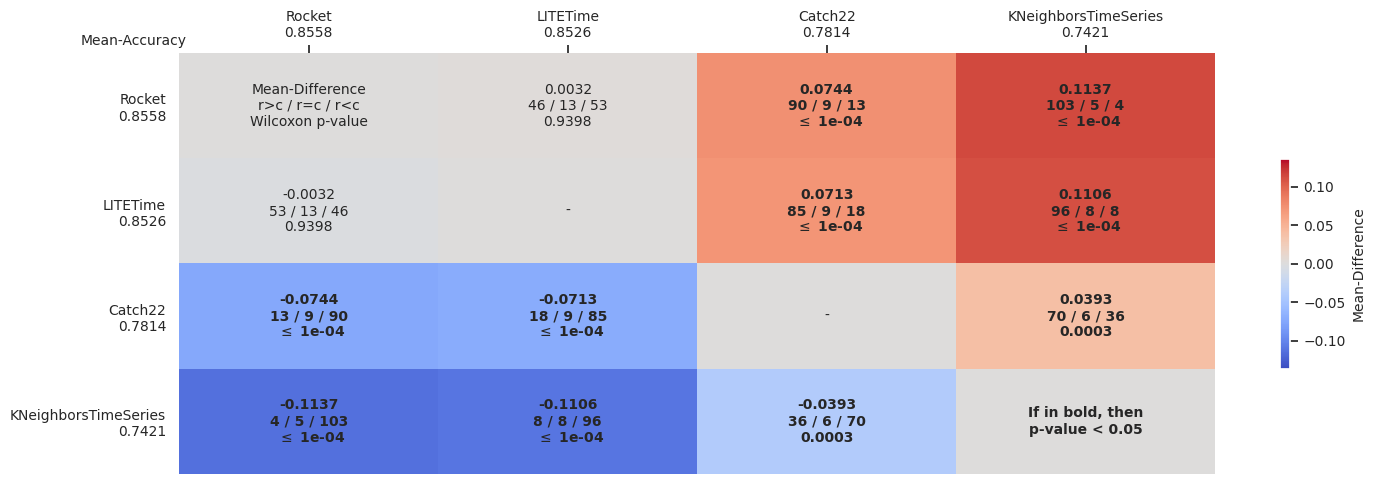

In [ ]:
from PIL import Image

img = Image.open('./heatmap.png')
img